Re-think of [jax_wcs_experimentation.ipynb](jax_wcs_experimentation.ipynb)

The core problem there was realizing that negative coefficients were impossible when using the bias-as-coefficience approach.  So instead consider the following formulation:

$w_k = \Sigma_i \Sigma_j A_{ij}x^i y^j $ 

$ = \Sigma_i \Sigma_j A_{ij} e^{i \ln{x} + j \ln{x}}$
$ = \Sigma_i \Sigma_j A_{ij} e^{p_{xy,i}}$ where $p_{xy,i} = i \ln{x} + j \ln{x}$

Which is equivalent to a linear/fully-connected layer *without bias* that takes ln(x) and ln(y) as input features, followed by an exponential activation and then another linear layer without an activation.

In [11]:
import time
from pathlib import Path
from matplotlib import pyplot as plt

import numpy as np

from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

import jax
from jax import numpy as jnp
import equinox as eqx
import optax

from tqdm.auto import tqdm

jax.devices()

[CudaDevice(id=0)]

In [ ]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
n6791dms = [datamodels.open(fn) for fn in n6791fits]

dm0 = n6791dms[0]
s = dm0.slits[42]
swcs = s.meta.wcs

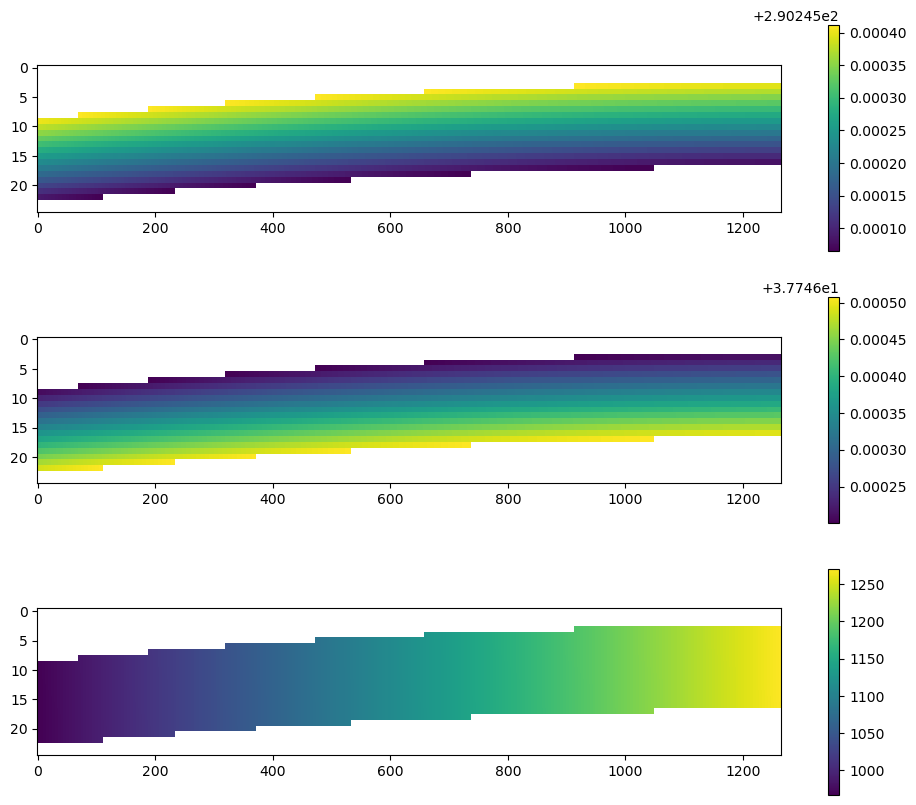

In [13]:
yg, xg = np.indices(s.data.shape)

sky,spec = swcs.pixel_to_world(xg, yg)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sc = ax1.imshow(sky.ra.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax1)
sc = ax2.imshow(sky.dec.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax2)
sc = ax3.imshow(spec.to_value(u.nm), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax3)

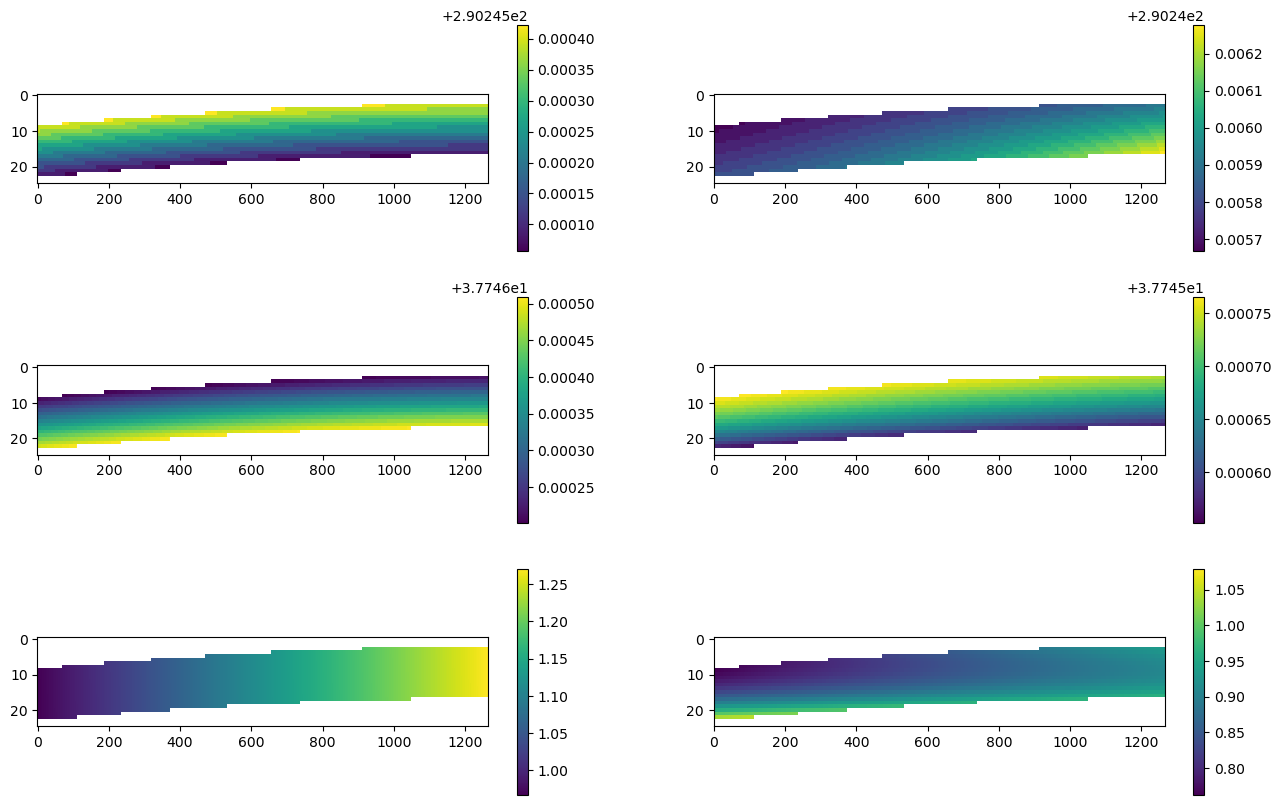

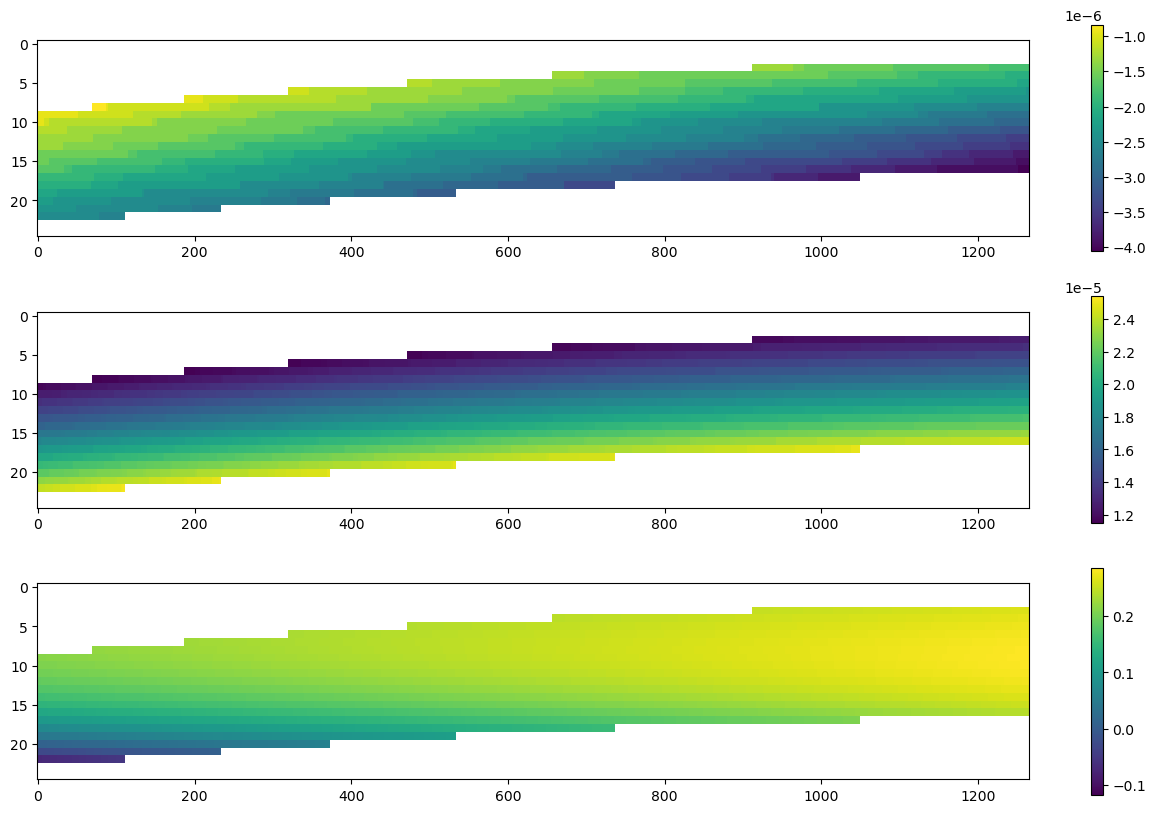

In [14]:
class LogPoly(eqx.Module):
    powers: jax.Array
    coeffs: jax.Array
    in_scale: jax.Array
    in_offset: jax.Array
    out_scale: jax.Array
    out_offset: jax.Array

    def __init__(self, ndegree, in_scale=None, in_offset=None, out_scale=None, out_offset=None, coeffs=None, powers=None):
        self.in_scale = jnp.ones(2) if in_scale is None else in_scale
        self.in_offset = jnp.zeros(2) if in_offset is None else in_offset
        self.out_scale = jnp.ones(3) if out_scale is None else out_scale
        self.out_offset = jnp.zeros(3) if out_offset is None else out_offset

        if powers is None:
            squarepowers = jnp.mgrid[:ndegree+1, :ndegree+1].reshape(2, -1).T
            self.powers = squarepowers[np.sum(squarepowers, axis=1) <= ndegree] # npoly, 2
        else:
            self.powers = powers
        self.coeffs = jnp.ones((3, self.powers.shape[0])) if coeffs is None else coeffs

    def __call__(self, xy):
        xy = (xy - self.in_offset[:, None]) / self.in_scale[:, None]
        logxy = jnp.log(xy)
        p = jnp.exp(self.powers @ logxy)
        flattened_p = p.reshape(p.size // p.shape[-1], -1)
        flattened_coeffs = self.coeffs.reshape(self.coeffs.size // self.coeffs.shape[0], -1).T
        rawout = flattened_coeffs @ flattened_p
        return (rawout.T * self.out_scale + self.out_offset).T
    
    @classmethod
    def make_from_data(cls, ndegree, xy, out, maskunfinite=True, powers=None):
        in_off = xy.min(axis=1) - 1
        in_scale = xy.ptp(axis=1)

        logxy = jnp.log((xy - in_off[:, None]) / in_scale[:, None])

        if maskunfinite:
            msk = jnp.isfinite(logxy).all(axis=0) & jnp.isfinite(out).all(axis=0)
            logxy = logxy[:, msk]
            out = out[:, msk]

        fakemod = cls(ndegree, powers=powers)
        p = jnp.exp(fakemod.powers @ logxy)
        flattened_p = p.reshape(p.size // p.shape[-1], -1)

        out_off = out.min(axis=1)
        out_scale = out.ptp(axis=1)

        rescaled_out = (out - out_off[:, None]) / out_scale[:, None]

        coeffs = jnp.linalg.lstsq(flattened_p.T, rescaled_out.T)[0].T

        return cls(ndegree, coeffs=coeffs, powers=powers, in_scale=in_scale, in_offset=in_off, out_scale=out_scale, out_offset=out_off)

mod = LogPoly(5)
xyg = jnp.stack([xg, yg], axis=0).reshape(2, -1)
w = jnp.array(swcs.pixel_to_world_values(xg, yg))
wr = w.reshape(3, -1)

mod = LogPoly.make_from_data(3, xyg, wr)
res = mod(xyg).reshape(3, *xg.shape)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(w, res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)


fig, axs = plt.subplots(3, 1, figsize=(16, 10))
for trueval, predval, ax in zip(w, res, axs):
    sc = ax.imshow(1-predval/trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)


Try optimizing w/ optax

  0%|          | 0/300 [00:00<?, ?it/s]

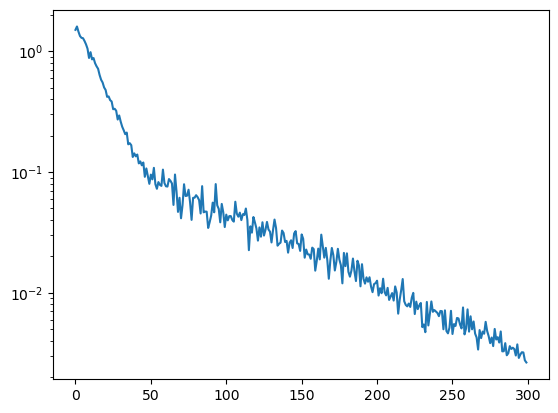

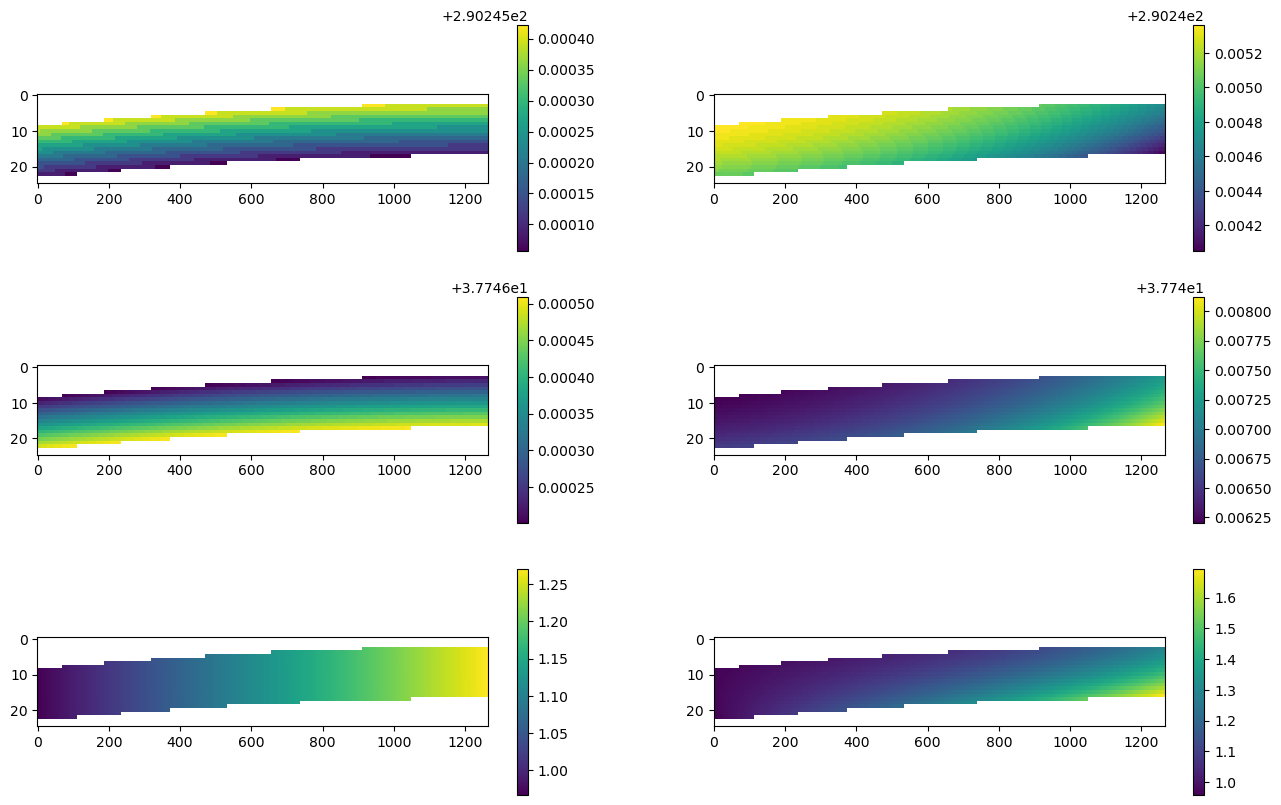

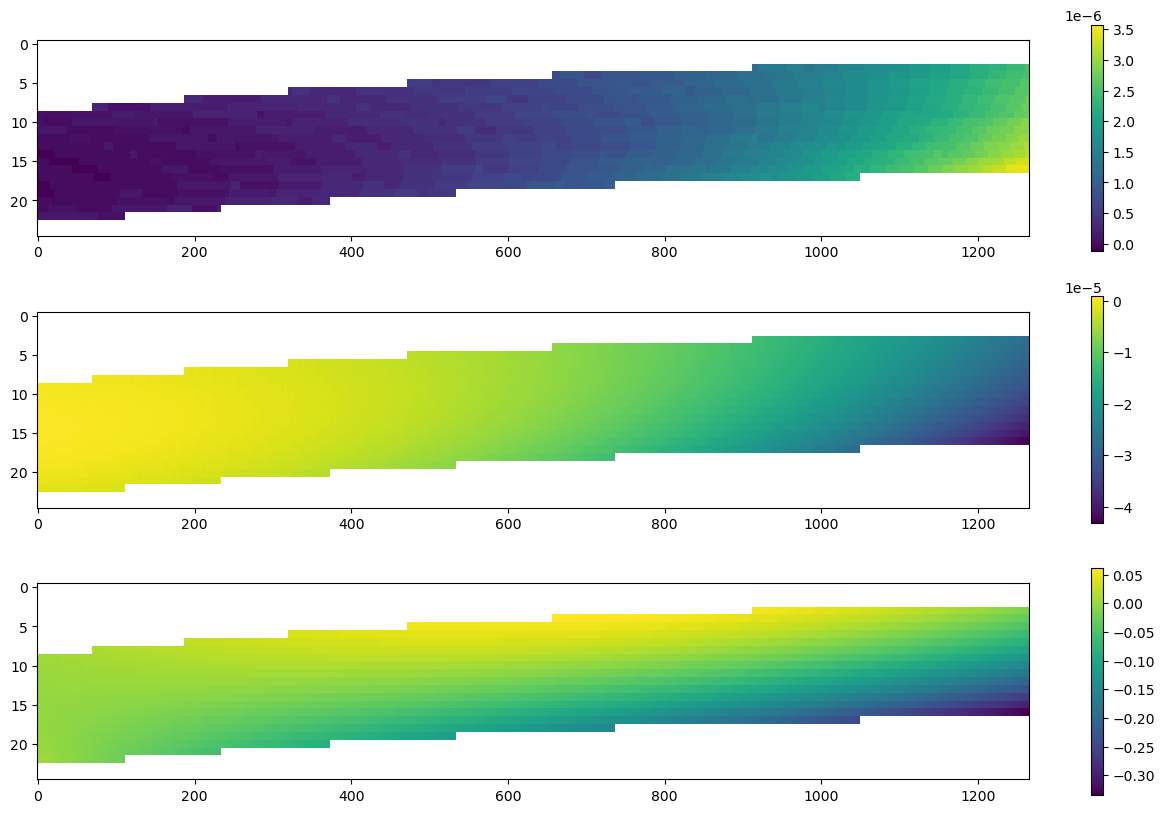

In [6]:
LEARNING_RATE = 1e-2
NITERS = 300
NBATCH = 1024

xyg = jnp.stack([xg, yg], axis=0).reshape(2, -1)
w = jnp.array(swcs.pixel_to_world_values(xg, yg))
wr = w.reshape(3, -1)
mod = LogPoly.make_from_data(6, xyg, wr)

optim = optax.adamw(LEARNING_RATE)

def filter_coeffs_only(module):
    return len(module.shape) > 1 and module.shape[0] == 3

coeffs_only = eqx.filter(mod, filter_coeffs_only)
opt_state = optim.init(coeffs_only)

def loss(mod, x, y):
    pred = mod(x)
    predr = (pred - mod.out_offset[:, None]) / mod.out_scale[:, None]
    yr = (y - mod.out_offset[:, None]) / mod.out_scale[:, None]
    return jnp.mean((predr - yr)**2)

@eqx.filter_jit
def update(model, opt_state, i, o):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, i, o)
    updates, opt_state = optim.update(
        eqx.filter(grads, filter_coeffs_only), opt_state, 
        eqx.filter(model, filter_coeffs_only)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value


key = jax.random.PRNGKey(0)
t = tqdm(range(NITERS))
losses = []
for i in t:
    key, k1, k2 = jax.random.split(key, 3)
    x, y = jax.random.uniform(k1, (2, 2*NBATCH))
    x = x*xg.shape[0]
    y = y*xg.shape[1]
    xy = jnp.stack([x, y], axis=0)
    wrs = jnp.array(swcs.pixel_to_world_values(x, y))

    msk = jnp.isfinite(wrs).all(axis=0)

    mod, opt_state, train_loss = update(mod, opt_state, xy[:, msk][:, :NBATCH], wrs[:,msk][:, :NBATCH])
    t.set_description(f"loss: {train_loss:.4}")
    losses.append(train_loss)

plt.semilogy(losses)

res = mod(xyg).reshape(3, *xg.shape)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(w, res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)


fig, axs = plt.subplots(3, 1, figsize=(16, 10))
for trueval, predval, ax in zip(w, res, axs):
    sc = ax.imshow(1-predval/trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)


Hmm... try holding the scaling information in a completely separate object?

# Reorganize separating the model from the data scaling

In [15]:
class SlitScaling:
    def __init__(self, slitshape, wcs, extra_in_offset=1): # not slitshape will be y,x not x,y despite wcs being the normal way
        self.slitshape = slitshape
        self.wcs = wcs
        self.extra_in_offset = extra_in_offset

        self._compute_inbounds()
        self._compute_outbounds()

    def _compute_inbounds(self):
        self.inscale = jnp.array((self.slitshape[1], self.slitshape[0]))
        self.inoffset = -self.extra_in_offset * jnp.ones(2)

    def _compute_outbounds(self):
        world = self.world_grid()
        worldflat = world.reshape(3, -1)
        self.outoffset = mi = jnp.nanmin(worldflat, axis=1)
        mx = jnp.nanmax(worldflat, axis=1)
        self.outscale = mx - mi

    def xy_grid(self):
        yg, xg = jnp.mgrid[:self.slitshape[0], :self.slitshape[1]]
        return jnp.stack([xg, yg[::-1]], axis=0)
    
    def world_grid(self):
        return jnp.array(self.wcs.pixel_to_world_values(*self.xy_grid()))
    
    def rescale_input(self, xy):
        return ((xy.T - self.inoffset) / self.inscale).T
    
    def rescale_output(self, out):
        return ((out.T - self.outoffset) / self.outscale).T
    
    def restore_output(self, outscaled):
        return (outscaled.T * self.outscale + self.outoffset).T

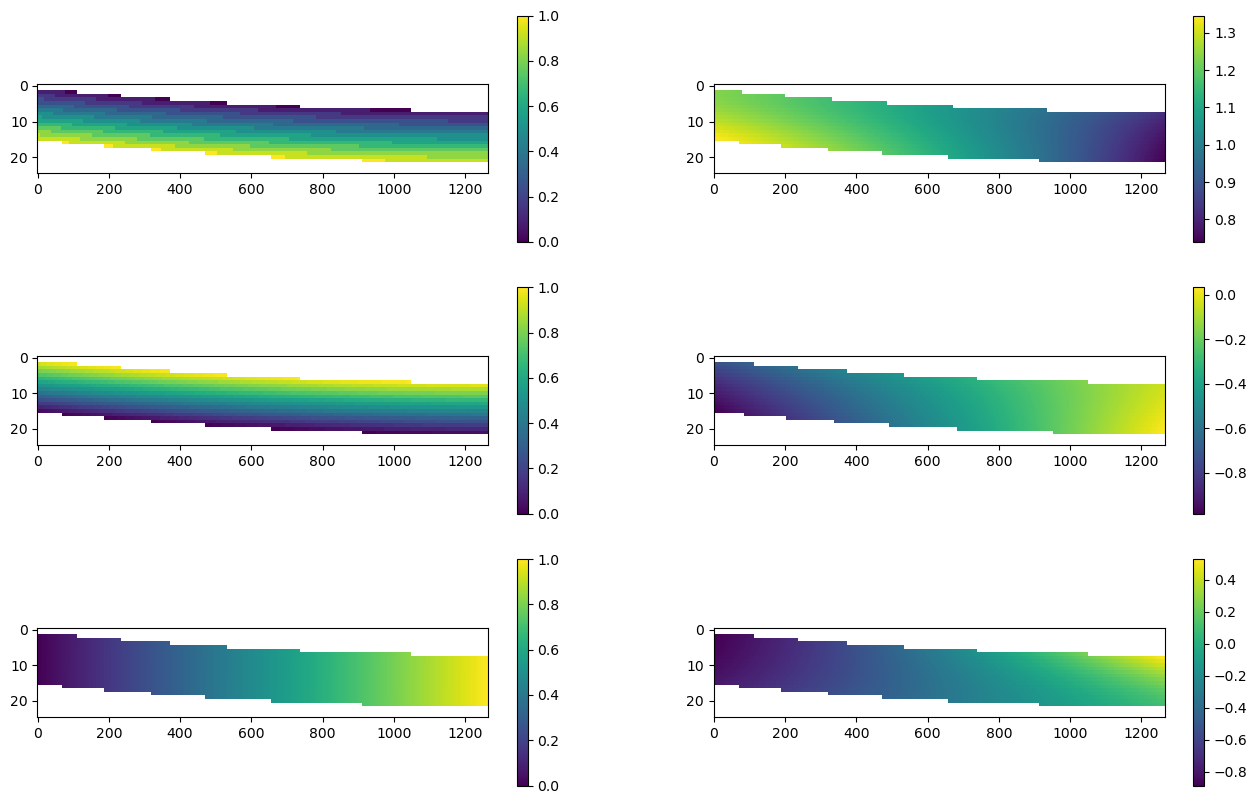

In [9]:
class LogPoly(eqx.Module):
    powers: jax.Array
    coeffs: jax.Array

    def __init__(self, ndegree, coeffs=None, powers=None):

        if powers is None:
            squarepowers = jnp.mgrid[:ndegree+1, :ndegree+1].reshape(2, -1).T
            self.powers = squarepowers[np.sum(squarepowers, axis=1) <= ndegree].astype(float) # npoly, 2
        else:
            self.powers = powers
        self.coeffs = jnp.ones((3, self.powers.shape[0])) if coeffs is None else coeffs

    def __call__(self, xy):
        logxy = jnp.log(xy)
        p = jnp.exp(self.powers @ logxy)
        flattened_p = p.reshape(p.size // p.shape[-1], -1)
        flattened_coeffs = self.coeffs.reshape(self.coeffs.size // self.coeffs.shape[0], -1).T
        return flattened_coeffs @ flattened_p
    
    @classmethod
    def make_from_data(cls, ndegree, xy, out, maskunfinite=True, powers=None, rcond=None):
        logxy = jnp.log(xy)

        if maskunfinite:
            msk = jnp.isfinite(logxy).all(axis=0) & jnp.isfinite(out).all(axis=0)
            logxy = logxy[:, msk]
            out = out[:, msk]

        fakemod = cls(ndegree, powers=powers)
        p = jnp.exp(fakemod.powers @ logxy)
        flattened_p = p.reshape(p.size // p.shape[-1], -1)

        res = jnp.linalg.lstsq(flattened_p.T, out.T, rcond=rcond)
        coeffs = res[0].T

        newobj = cls(ndegree, coeffs=coeffs, powers=powers)
        
        return newobj, res
    

ss = SlitScaling(s.data.shape, swcs, extra_in_offset=0)

xyr = ss.rescale_input(ss.xy_grid()).reshape(2, -1)
truer = ss.rescale_output(ss.world_grid()).reshape(3, -1)

mod, lstsq_result = LogPoly.make_from_data(4, xyr, truer)

res = mod(xyr).reshape(3, *ss.slitshape)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(truer, res, axs):
    t = trueval.reshape(ss.slitshape)
    sc = ax1.imshow(t, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval.reshape(ss.slitshape) + t/t - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)


## Adam optimized

  0%|          | 0/2000 [00:00<?, ?it/s]

(15, 1024) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)


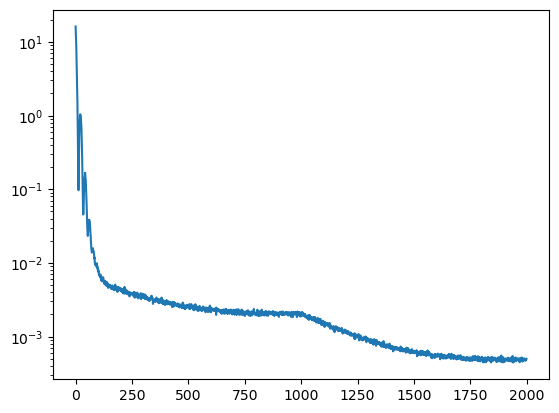

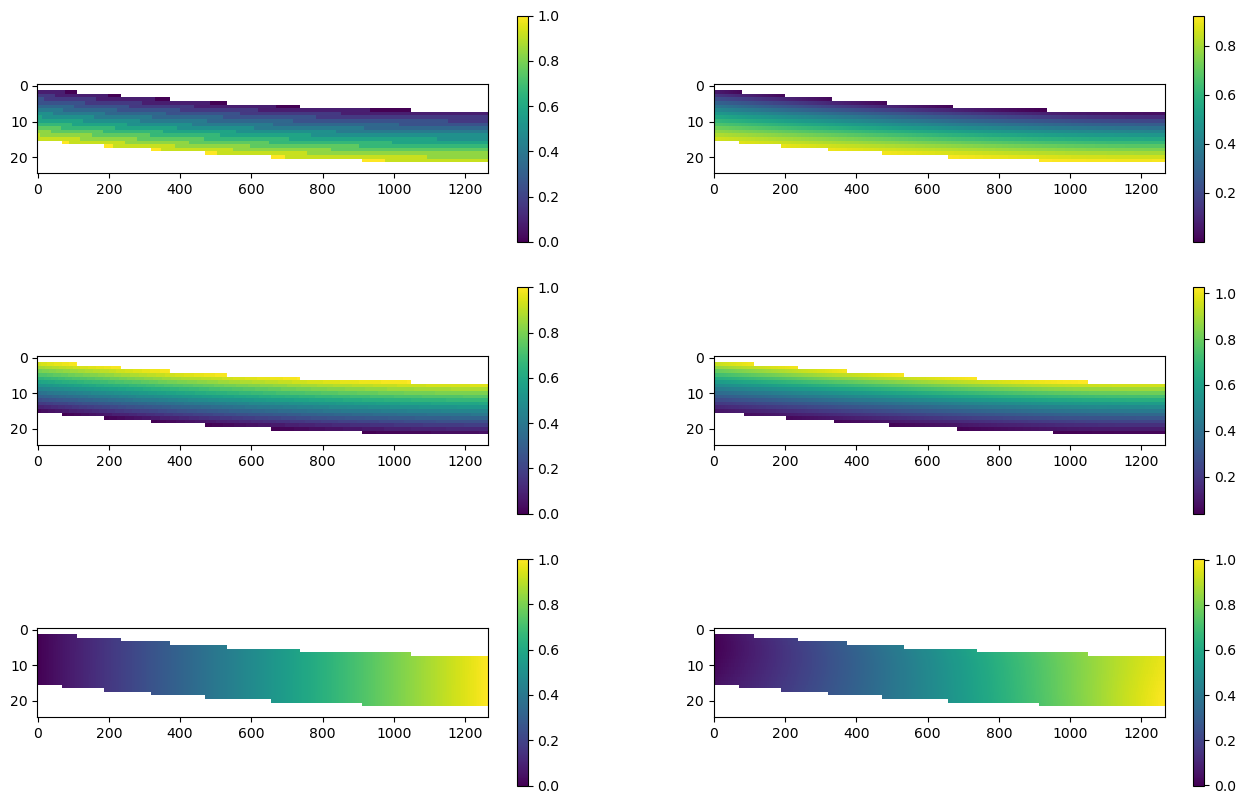

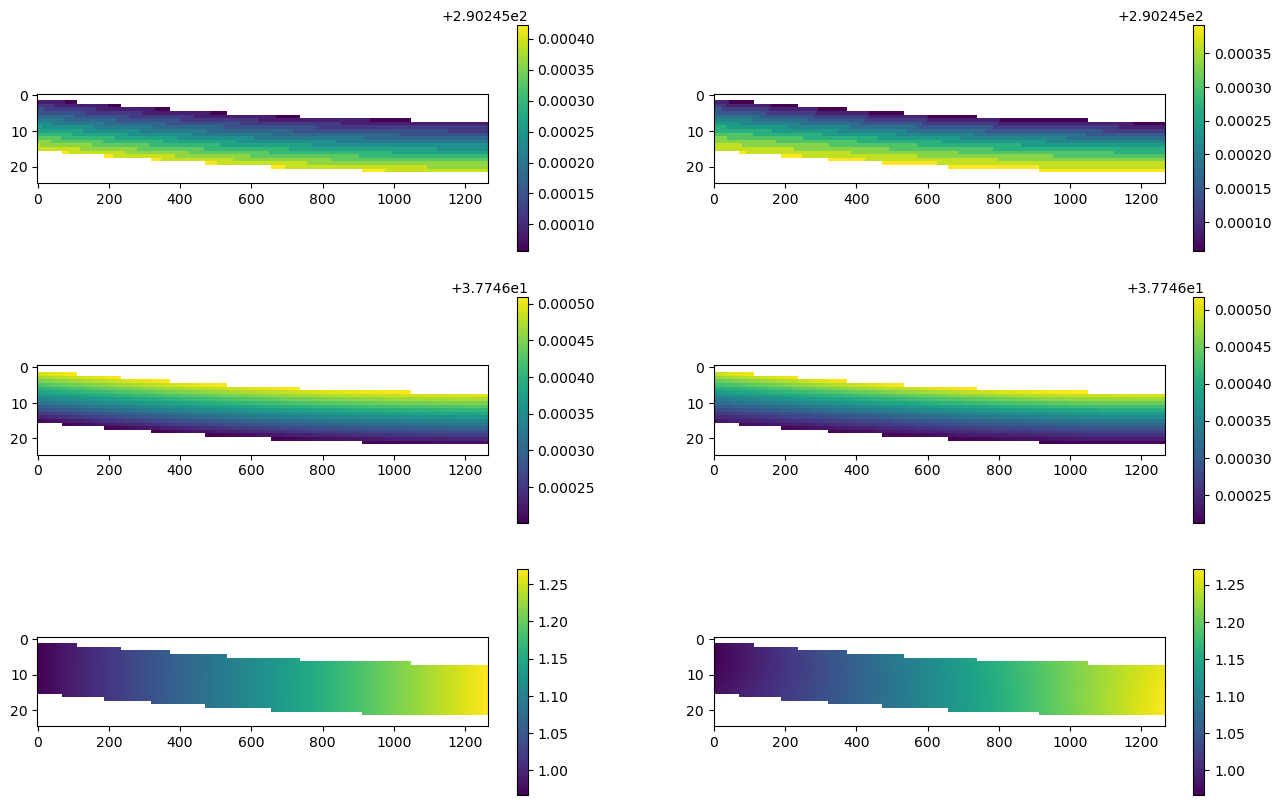

In [618]:
LEARNING_RATES = (8e-2, 2e-3)
NITERS = 2000
NBATCH = 1024


ss = SlitScaling(s.data.shape, swcs)

xyg = ss.xy_grid()
xygr = ss.rescale_input(xyg).reshape(2, -1)
w = ss.world_grid()
wr = w.reshape(3, -1)
mod = LogPoly(4)

cosched = optax.cosine_decay_schedule(LEARNING_RATES[0], NITERS//2, LEARNING_RATES[1])
lrsched = optax.join_schedules([cosched, cosched], [NITERS//2])
optim = optax.adamw(lrsched)

def filter_coeffs_only(module):
    return len(module.shape) > 1 and module.shape[0] == 3

coeffs_only = eqx.filter(mod, filter_coeffs_only)
opt_state = optim.init(coeffs_only)

def loss(mod, x, y):
    return jnp.mean((mod(x) - y)**2)

@eqx.filter_jit
def update(model, opt_state, i, o):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, i, o)
    updates, opt_state = optim.update(
        eqx.filter(grads, filter_coeffs_only), opt_state, 
        eqx.filter(model, filter_coeffs_only)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value


key = jax.random.PRNGKey(0)
t = tqdm(range(NITERS))
losses = []
for i in t:
    key, k1, k2 = jax.random.split(key, 3)
    x, y = jax.random.uniform(k1, (2, 2*NBATCH))
    x = x*ss.slitshape[1]
    y = y*ss.slitshape[0]
    xy = ss.rescale_input(jnp.stack([x, y], axis=0))
    wrs = ss.rescale_output(jnp.array(swcs.pixel_to_world_values(x, y)))

    msk = jnp.isfinite(wrs).all(axis=0)

    mod, opt_state, train_loss = update(mod, opt_state, xy[:, msk][:, :NBATCH], wrs[:,msk][:, :NBATCH])
    t.set_description(f"loss: {train_loss:.4}")
    losses.append(train_loss)

plt.semilogy(losses)


res = mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1)).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(ss.rescale_output(ss.world_grid()), res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)

    res = ss.restore_output(mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1))).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(w, res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)

(15, 31650) (3, 15)


(Array([0.06190022, 0.08561198, 0.06506068], dtype=float32),
 Array([0.05910429, 0.07642946, 0.05535955], dtype=float32))

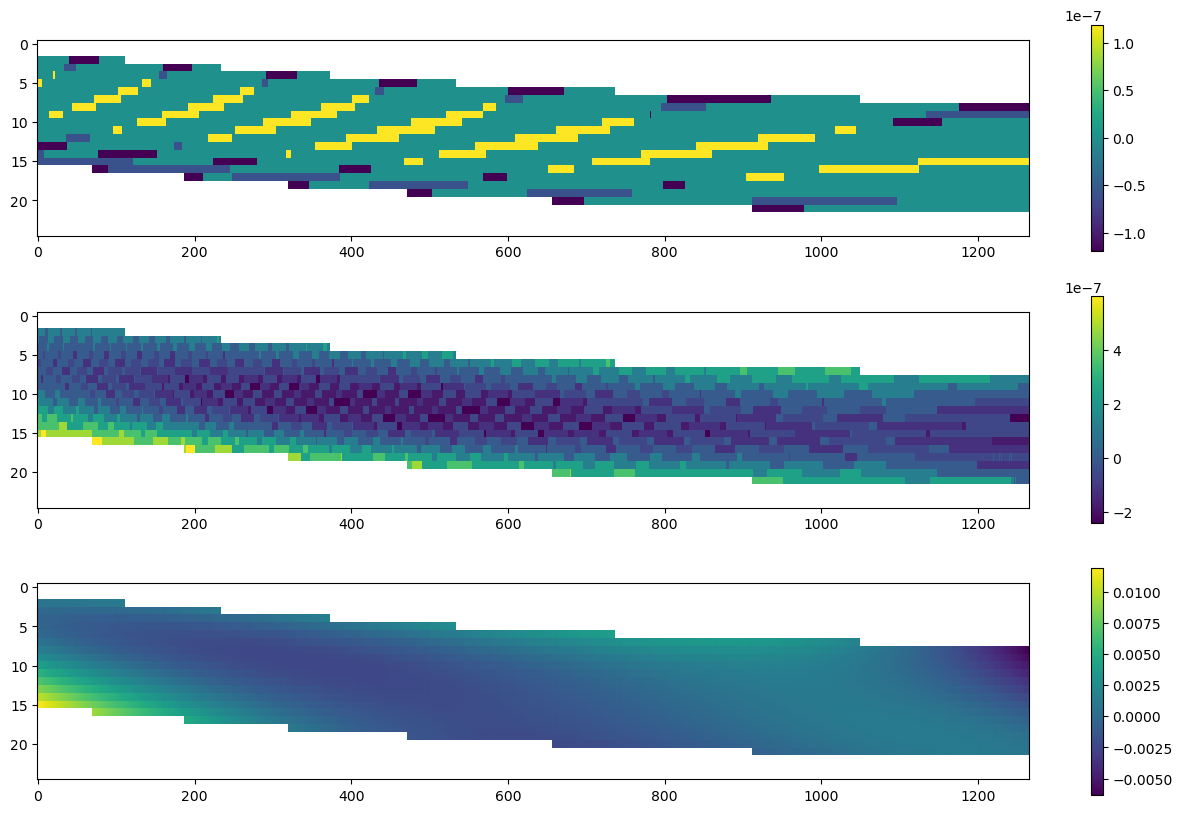

In [619]:
res = ss.restore_output(mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1))).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 1, figsize=(16, 10))
for trueval, predval, ax in zip(w, res, axs):
    sc = ax.imshow(predval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax)

truevalr = trueval.reshape(3, -1)
jnp.nanstd(truevalr, axis=1), jnp.nanstd(truevalr.T/jnp.nanmean(truevalr, axis=1), axis=0)

Ok so we should be able to get there.  What if we then refine allowing the powers to vary?

  0%|          | 0/1000 [00:00<?, ?it/s]

(15, 4096) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)


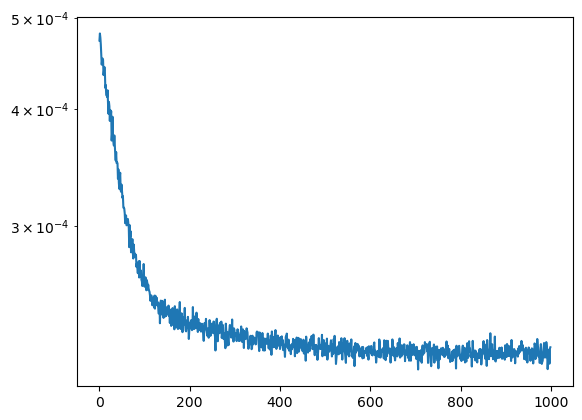

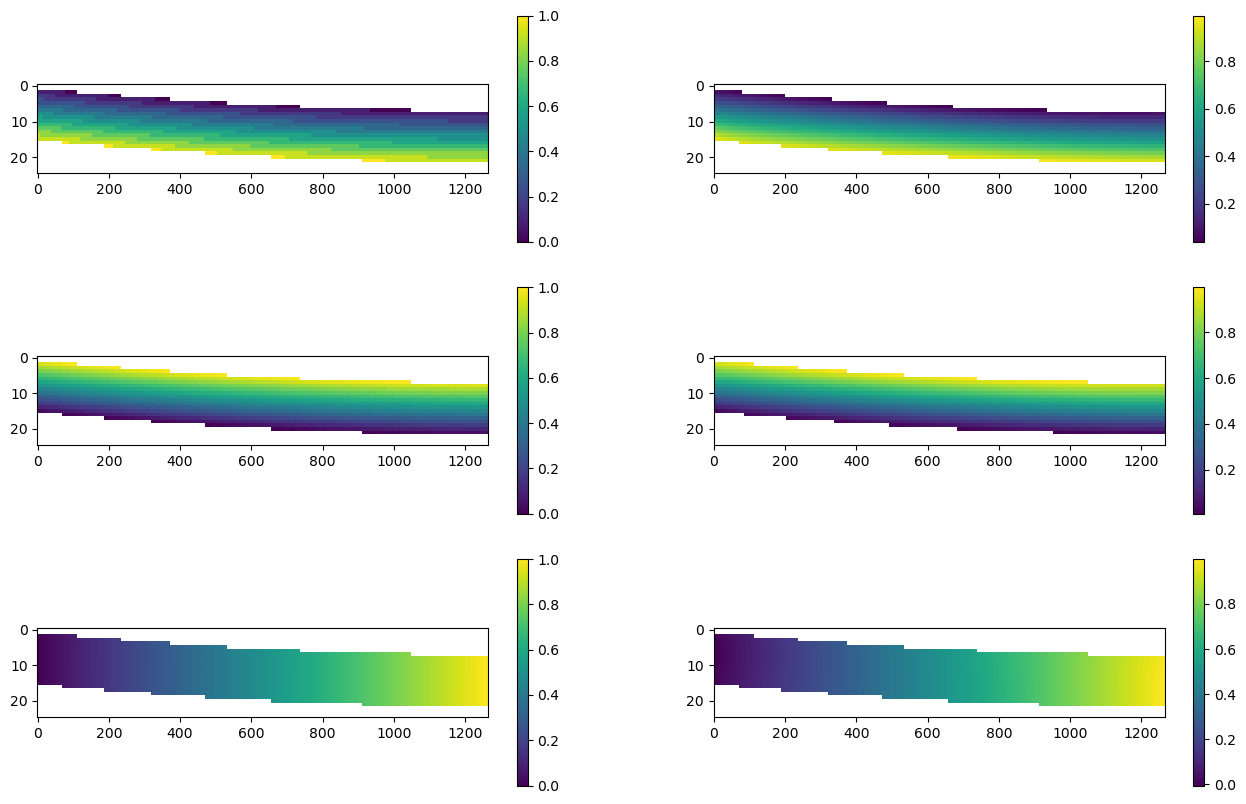

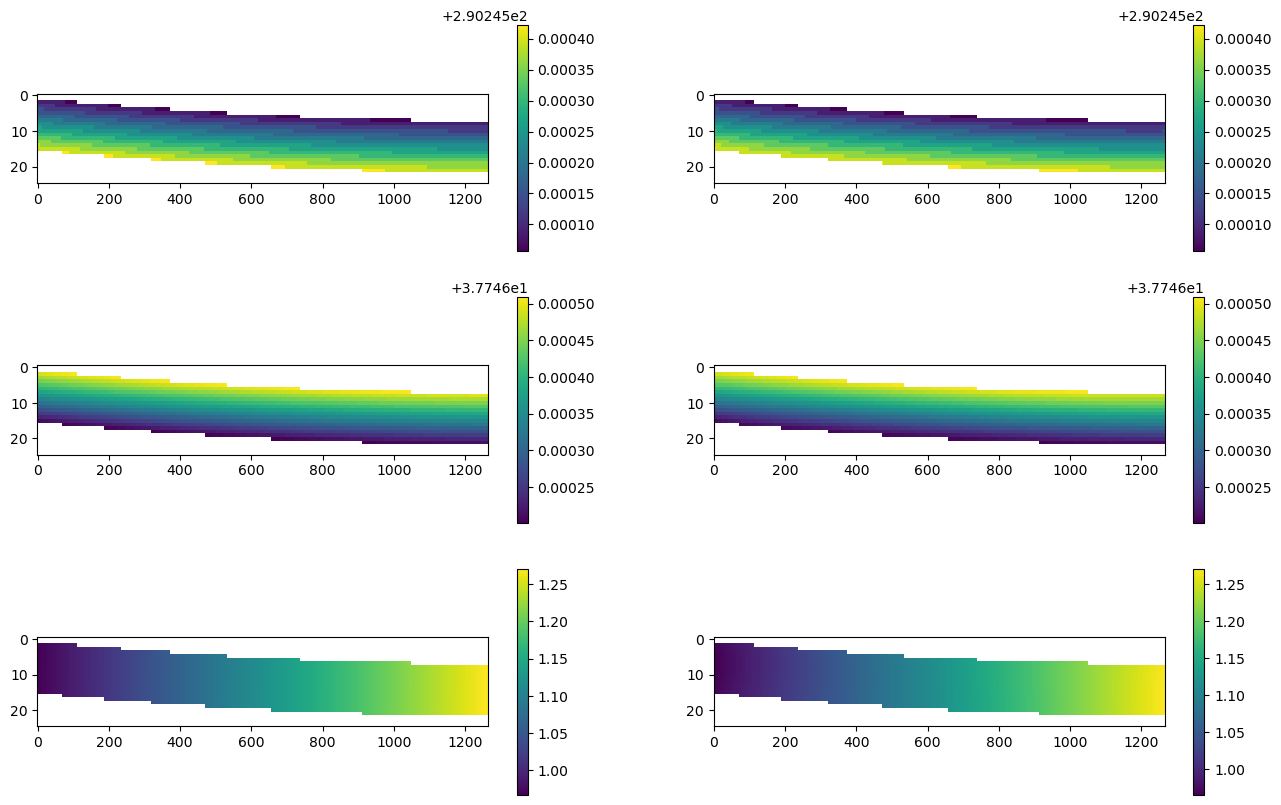

In [620]:
LEARNING_RATES = (1e-3, 5e-5)
NITERS = 1000
NBATCH = 4096



cosched = optax.cosine_decay_schedule(LEARNING_RATES[0], NITERS, LEARNING_RATES[1])
optim = optax.adamw(cosched)

def paramfilter(leaf):
    return True

coeffs_only = eqx.filter(mod, paramfilter)
opt_state = optim.init(coeffs_only)

def loss(mod, x, y):
    return jnp.mean((mod(x) - y)**2)

@eqx.filter_jit
def update(model, opt_state, i, o):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, i, o)
    updates, opt_state = optim.update(
        eqx.filter(grads, paramfilter), opt_state, 
        eqx.filter(model, paramfilter)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value


key = jax.random.PRNGKey(0)
t = tqdm(range(NITERS))
losses = []
for i in t:
    key, k1, k2 = jax.random.split(key, 3)
    x, y = jax.random.uniform(k1, (2, 2*NBATCH))
    x = x*ss.slitshape[1]
    y = y*ss.slitshape[0]
    xy = ss.rescale_input(jnp.stack([x, y], axis=0))
    wrs = ss.rescale_output(jnp.array(swcs.pixel_to_world_values(x, y)))

    msk = jnp.isfinite(wrs).all(axis=0)

    mod, opt_state, train_loss = update(mod, opt_state, xy[:, msk][:, :NBATCH], wrs[:,msk][:, :NBATCH])
    t.set_description(f"loss: {train_loss:.4}")
    losses.append(train_loss)

plt.semilogy(losses)


res = mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1)).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(ss.rescale_output(ss.world_grid()), res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)

res = ss.restore_output(mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1))).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(w, res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)

(15, 31650) (3, 15)


(Array([0.06190022, 0.08561198, 0.06506068], dtype=float32),
 Array([0.05910429, 0.07642946, 0.05535955], dtype=float32))

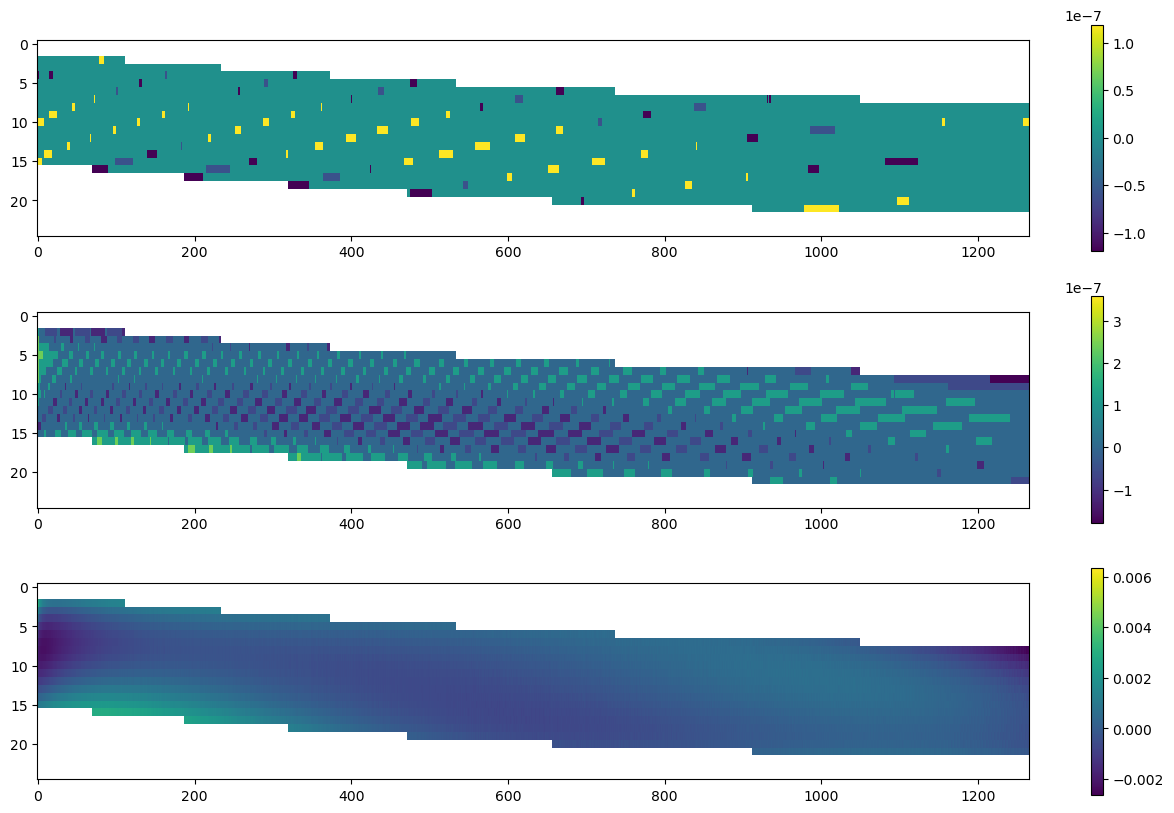

In [621]:
res = ss.restore_output(mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1))).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 1, figsize=(16, 10))
for trueval, predval, ax in zip(w, res, axs):
    sc = ax.imshow(predval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax)

truevalr = trueval.reshape(3, -1)
jnp.nanstd(truevalr, axis=1), jnp.nanstd(truevalr.T/jnp.nanmean(truevalr, axis=1), axis=0)

## Try fitting the spectral part separately

  0%|          | 0/2000 [00:00<?, ?it/s]

(15, 1024) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)
(15, 31650) (3, 15)


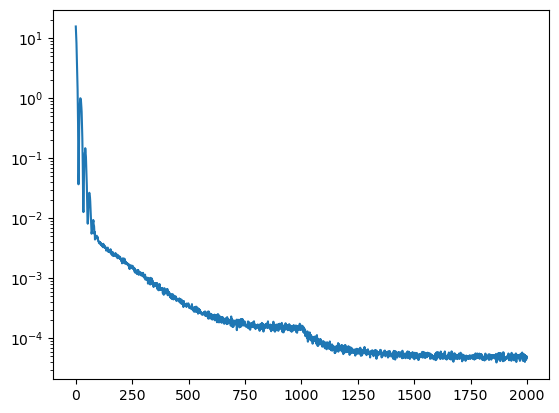

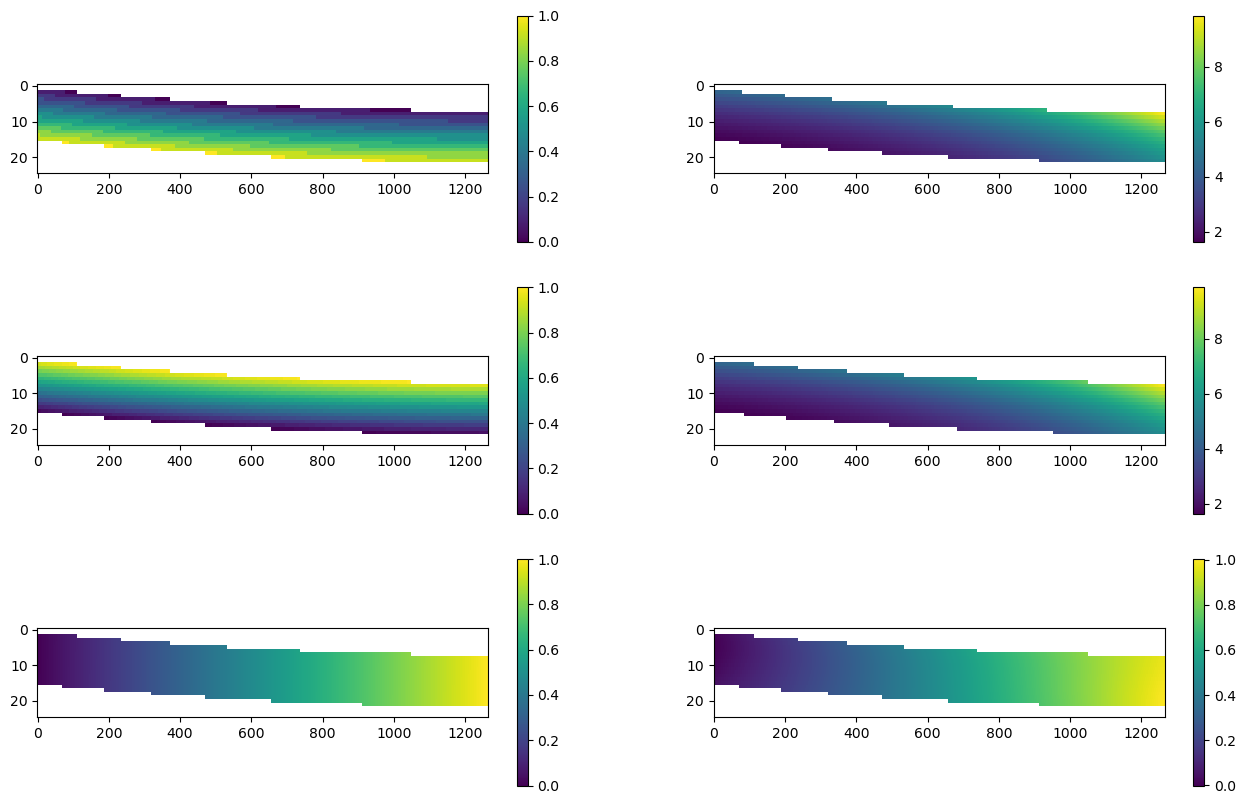

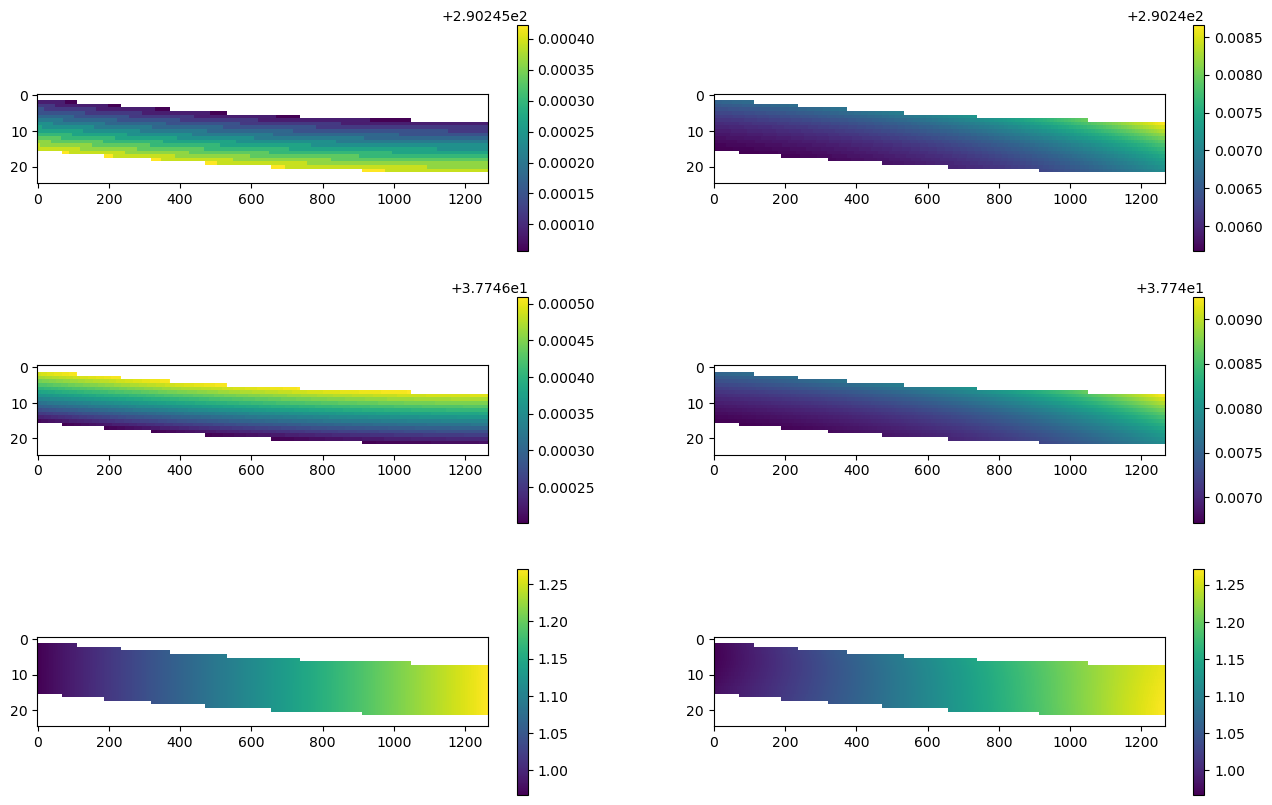

In [ ]:
LEARNING_RATES = (8e-2, 2e-3)
NITERS = 2000
NBATCH = 1024


ss = SlitScaling(s.data.shape, swcs)

xyg = ss.xy_grid()
xygr = ss.rescale_input(xyg).reshape(2, -1)
w = ss.world_grid()
wr = w.reshape(3, -1)
mod = LogPoly(4)

cosched = optax.cosine_decay_schedule(LEARNING_RATES[0], NITERS//2, LEARNING_RATES[1])
lrsched = optax.join_schedules([cosched, cosched], [NITERS//2])
optim = optax.adamw(lrsched)

def filter_coeffs_only(module):
    return len(module.shape) > 1 and module.shape[0] == 3

coeffs_only = eqx.filter(mod, filter_coeffs_only)
opt_state = optim.init(coeffs_only)

def loss(mod, x, y):
    return jnp.mean((mod(x)[-1] - y[-1])**2)

@eqx.filter_jit
def update(model, opt_state, i, o):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, i, o)
    updates, opt_state = optim.update(
        eqx.filter(grads, filter_coeffs_only), opt_state, 
        eqx.filter(model, filter_coeffs_only)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value


key = jax.random.PRNGKey(0)
t = tqdm(range(NITERS))
losses = []
for i in t:
    key, k1, k2 = jax.random.split(key, 3)
    x, y = jax.random.uniform(k1, (2, 2*NBATCH))
    x = x*ss.slitshape[1]
    y = y*ss.slitshape[0]
    xy = ss.rescale_input(jnp.stack([x, y], axis=0))
    wrs = ss.rescale_output(jnp.array(swcs.pixel_to_world_values(x, y)))

    msk = jnp.isfinite(wrs).all(axis=0)

    mod, opt_state, train_loss = update(mod, opt_state, xy[:, msk][:, :NBATCH], wrs[:,msk][:, :NBATCH])
    t.set_description(f"loss: {train_loss:.4}")
    losses.append(train_loss)

plt.semilogy(losses)


res = mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1)).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(ss.rescale_output(ss.world_grid()), res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)

res = ss.restore_output(mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1))).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for trueval, predval, (ax1, ax2) in zip(w, res, axs):
    sc = ax1.imshow(trueval, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(predval + trueval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax2)

(15, 31650) (3, 15)


(Array([0.06190022, 0.08561198, 0.06506068], dtype=float32),
 Array([0.05910429, 0.07642946, 0.05535955], dtype=float32))

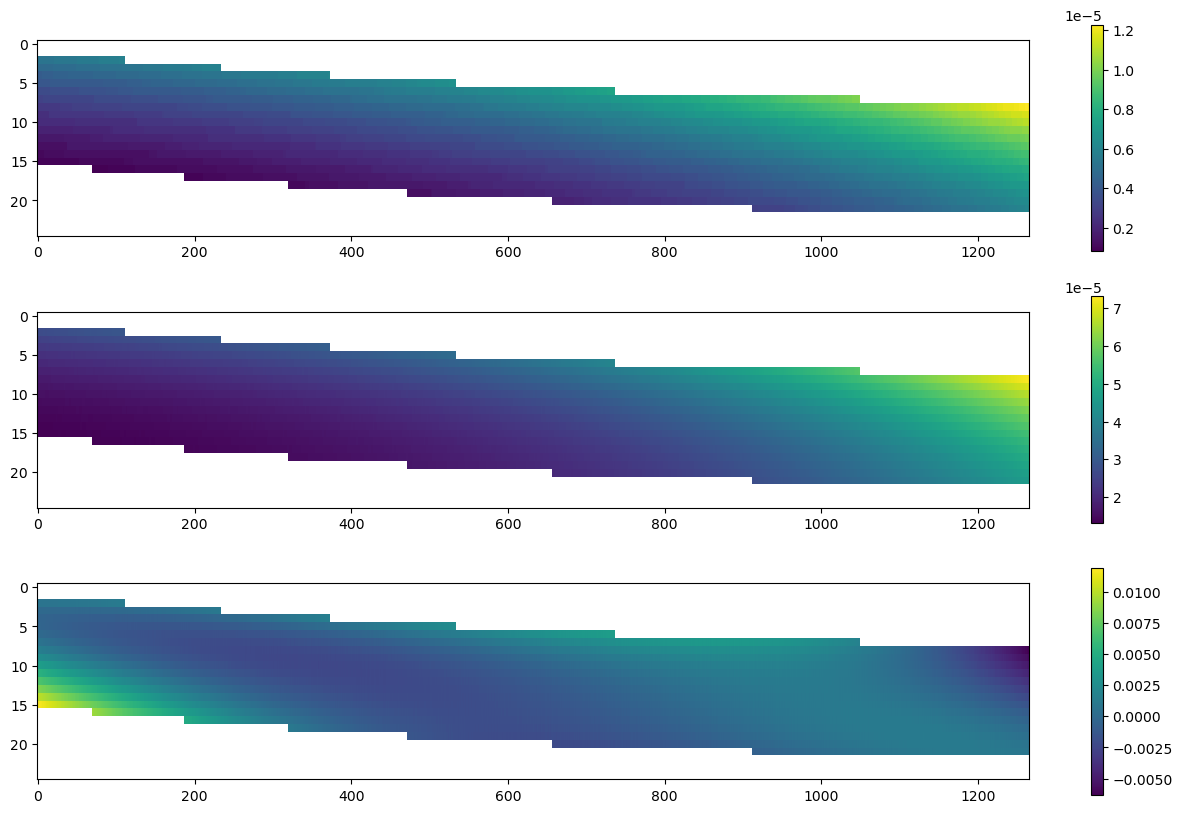

In [625]:
res = ss.restore_output(mod(ss.rescale_input(ss.xy_grid()).reshape(2, -1))).reshape(3, *xg.shape)
fig, axs = plt.subplots(3, 1, figsize=(16, 10))
for trueval, predval, ax in zip(w, res, axs):
    sc = ax.imshow(predval/trueval - 1, aspect=10, interpolation='nearest') # this is a trick that carries over the nans
    plt.colorbar(sc, ax=ax)

truevalr = trueval.reshape(3, -1)
jnp.nanstd(truevalr, axis=1), jnp.nanstd(truevalr.T/jnp.nanmean(truevalr, axis=1), axis=0)

# Over-simplified version

In [16]:
yg, xg = np.mgrid[:s.data.shape[0], :s.data.shape[1]]
yg = yg[::-1]

In [60]:
ndeg = 3
powers = np.array(np.mgrid[:ndeg+1, :ndeg+1]).reshape(2, -1)
powers = powers[:, np.sum(powers, axis=0)<=ndeg]
powers

array([[0, 0, 0, 0, 1, 1, 1, 2, 2, 3],
       [0, 1, 2, 3, 0, 1, 2, 0, 1, 0]])

In [18]:
p = xg.ravel()**powers[0][:,None]*yg.ravel()**powers[1][:,None]
worlds = np.array(swcs.pixel_to_world_values(xg, yg)).reshape(3, -1)
p.shape, worlds.shape

((10, 31650), (3, 31650))

In [19]:
msk = np.isfinite(worlds).all(axis=0)
pm = p[:, msk]
worldsm = worlds[:, msk]
pm.shape, worldsm.shape

((10, 18146), (3, 18146))

In [20]:
res = np.linalg.lstsq(pm.T, worldsm[0])
c0 = res[0]
res

(array([ 2.90245620e+02, -2.41459150e-05, -2.72544838e-10, -9.75734422e-14,
        -2.25496064e-07, -4.91216339e-11, -2.03949728e-14,  8.52609229e-11,
         1.94663536e-14, -1.57277995e-15]),
 array([3.06412453e-13]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170046e+04, 4.78545160e+03, 2.03118291e+03,
        5.15970146e+01, 2.26598055e+00]))

In [21]:
res = np.linalg.lstsq(pm.T, worldsm[1])
c1 = res[0]
res

(array([ 3.77460150e+01,  2.14305229e-05,  2.41558645e-10,  1.13843732e-13,
         2.00137293e-07,  4.36042627e-11,  1.83004861e-14, -7.56726819e-11,
        -1.72805557e-14,  1.39591520e-15]),
 array([2.41356942e-13]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170046e+04, 4.78545160e+03, 2.03118291e+03,
        5.15970146e+01, 2.26598055e+00]))

In [22]:
res = np.linalg.lstsq(pm.T, worldsm[2])
c2 = res[0]
res

(array([ 9.67362107e-01, -1.74745626e-05, -1.09010524e-09, -2.99095456e-11,
         2.41030763e-04, -6.70421702e-10, -8.07995226e-13, -6.81336664e-10,
         1.16166003e-13, -1.10322752e-13]),
 array([1.76318843e-09]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170046e+04, 4.78545160e+03, 2.03118291e+03,
        5.15970146e+01, 2.26598055e+00]))

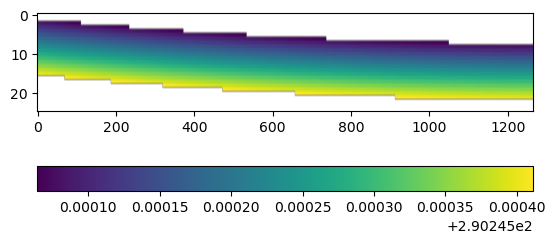

In [23]:
plt.imshow(worlds[0].reshape(xg.shape),aspect=10)
plt.colorbar(orientation='horizontal')

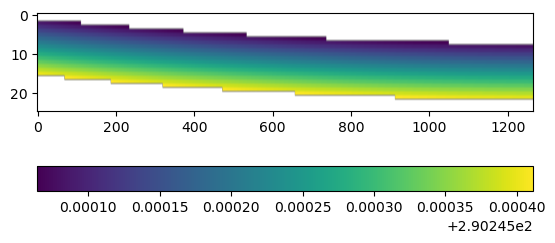

In [24]:
plt.imshow((p.T @ c0).reshape(xg.shape) + (worlds[0].reshape(xg.shape)-worlds[0].reshape(xg.shape)),aspect=10)
plt.colorbar(orientation='horizontal')

In [85]:
np.linalg.lstsq(pm.T, worldsm.T, rcond=1e-14)

(array([[ 2.90245620e+02,  3.77460150e+01,  9.67362107e-01],
        [-2.41459150e-05,  2.14305229e-05, -1.74745626e-05],
        [-2.72544838e-10,  2.41558034e-10, -1.09010524e-09],
        [-9.75734422e-14,  1.13860185e-13, -2.99095456e-11],
        [-2.25496064e-07,  2.00137293e-07,  2.41030763e-04],
        [-4.91216339e-11,  4.36042703e-11, -6.70421702e-10],
        [-2.03949728e-14,  1.83004107e-14, -8.07995226e-13],
        [ 8.52609229e-11, -7.56726818e-11, -6.81336664e-10],
        [ 1.94663536e-14, -1.72805669e-14,  1.16166003e-13],
        [-1.57277995e-15,  1.39591545e-15, -1.10322752e-13]]),
 array([3.06412453e-13, 2.41356869e-13, 1.76318843e-09]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170046e+04, 4.78545160e+03, 2.03118291e+03,
        5.15970146e+01, 2.26598055e+00]))

So that should be acheivable...  Lets try a re-implementation

## raw powering

In [89]:
np.linalg.lstsq(xyp[msk], worldsm.T, rcond=1e-14)

(array([[ 2.90245620e+02,  3.77460150e+01,  9.67362107e-01],
        [-2.41459161e-05,  2.14305239e-05, -1.74745634e-05],
        [-2.72476960e-10,  2.41494306e-10, -1.09005215e-09],
        [-9.92041229e-14,  1.15406779e-13, -2.99108257e-11],
        [-2.25496068e-07,  2.00137296e-07,  2.41030763e-04],
        [-4.91216163e-11,  4.36040348e-11, -6.70421485e-10],
        [-2.03830018e-14,  1.83008170e-14, -8.07996299e-13],
        [ 8.52609247e-11, -7.56726809e-11, -6.81336664e-10],
        [ 1.94661428e-14, -1.72805429e-14,  1.16165967e-13],
        [-1.57277595e-15,  1.39591279e-15, -1.10322746e-13]]),
 array([3.06412401e-13, 2.41356828e-13, 1.76318833e-09]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170047e+04, 4.78545163e+03, 2.03118291e+03,
        5.15970127e+01, 2.26598055e+00]))

In [61]:
def make_powers(ndeg):
    powers = jnp.mgrid[:ndeg+1, :ndeg+1].reshape(2, -1)
    return powers[:, powers.sum(axis=0) <= ndeg]
make_powers(3)

Array([[0, 0, 0, 0, 1, 1, 1, 2, 2, 3],
       [0, 1, 2, 3, 0, 1, 2, 0, 1, 0]], dtype=int32)

In [64]:
ndeg = 3

xyg = ss.xy_grid().astype(float)
xygr = xyg.reshape(2,-1)
worldg = ss.world_grid()
worldgr = worldg.reshape(3,-1)

powers = make_powers(ndeg).astype(float)
xyp = np.prod(xygr.T[...,None]**powers, axis=1)

msk = np.isfinite(worldgr).all(axis=0)

jres = jnp.linalg.lstsq(xyp[msk], worldgr.T[msk], rcond=1e-14)
jres

(Array([[ 2.9024652e+02,  3.7746613e+01,  9.6709478e-01],
        [-8.5830688e-06, -4.5001507e-06,  1.6679987e-06],
        [-1.0013580e-05, -1.5199184e-06, -1.8673018e-07],
        [ 3.2037497e-07,  5.6345016e-08, -2.2555469e-09],
        [-6.7800283e-07, -1.2293458e-07,  2.4121470e-04],
        [ 5.9604645e-08, -4.8894435e-09, -1.4697434e-09],
        [-1.7462298e-09,  5.6752469e-10, -2.2987479e-10],
        [-1.2514647e-09, -3.6743586e-10, -6.5790573e-10],
        [ 7.2759576e-12,  1.3528734e-11, -5.8584249e-12],
        [ 3.4772185e-13,  3.2807090e-14,  2.1921718e-12]], dtype=float32),
 Array([0.00429857, 0.00052304, 0.0564093 ], dtype=float32),
 Array(10, dtype=int32),
 Array([1.0262336e+11, 4.4714413e+08, 1.4285009e+07, 3.8689602e+06,
        2.1935666e+05, 7.8022234e+04, 5.3563374e+03, 2.2152913e+03,
        9.0530927e+02, 1.0674709e+00], dtype=float32))

In [65]:
npres = np.linalg.lstsq(np.array(xyp[msk]).astype(np.float32), np.array(worldgr.T[msk]).astype(np.float32), rcond=1e-14)
npres

(array([[ 2.9024561e+02,  3.7746014e+01,  9.6736211e-01],
        [-2.1692456e-05,  2.1500598e-05, -1.7472612e-05],
        [-1.5299091e-07, -4.3646669e-09, -1.2050199e-09],
        [ 3.2290481e-09,  9.7564158e-11, -2.7574092e-11],
        [-2.0398451e-07,  2.0066190e-07,  2.4103078e-04],
        [-2.1091477e-09, -1.4833077e-11, -6.7154876e-10],
        [ 4.3463871e-11,  1.6064300e-12, -7.7597949e-13],
        [ 7.0255045e-11, -7.6007159e-11, -6.8133610e-10],
        [ 8.0029212e-13,  1.2130632e-15,  1.1618914e-13],
        [ 1.2985259e-15,  1.4526306e-15, -1.1032462e-13]], dtype=float32),
 array([1.4490014e-06, 2.2060588e-08, 1.7812199e-09], dtype=float32),
 np.int32(10),
 array([1.0262338e+11, 4.4714419e+08, 1.4285003e+07, 3.8689602e+06,
        2.1935623e+05, 7.8017008e+04, 4.7854517e+03, 2.0311829e+03,
        5.1597012e+01, 2.2659805e+00], dtype=float32))

In [103]:
npres = np.linalg.lstsq(np.array(xyp[msk]).astype(np.float64), np.array(worldgr.T[msk]).astype(np.float64), rcond=1e-14)
npres

(array([[ 2.90245607e+02,  3.77460147e+01,  9.67362096e-01],
        [-2.16924565e-05,  2.15005982e-05, -1.74726116e-05],
        [-1.52990914e-07, -4.36466692e-09, -1.20501985e-09],
        [ 3.22904808e-09,  9.75641568e-11, -2.75740924e-11],
        [-2.03984512e-07,  2.00661895e-07,  2.41030774e-04],
        [-2.10914779e-09, -1.48330771e-11, -6.71548739e-10],
        [ 4.34638725e-11,  1.60643000e-12, -7.75979510e-13],
        [ 7.02550414e-11, -7.60071579e-11, -6.81336117e-10],
        [ 8.00292109e-13,  1.21306317e-15,  1.16189131e-13],
        [ 1.29852589e-15,  1.45263056e-15, -1.10324617e-13]]),
 array([1.44900144e-06, 2.20605881e-08, 1.78121999e-09]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170047e+04, 4.78545163e+03, 2.03118291e+03,
        5.15970127e+01, 2.26598055e+00]))

In [107]:
npres = np.linalg.lstsq(np.array(xyp[msk]).astype(np.float64), np.array(worldsm.T).astype(np.float64), rcond=1e-14)
npres

(array([[ 2.90245620e+02,  3.77460150e+01,  9.67362107e-01],
        [-2.41459161e-05,  2.14305239e-05, -1.74745634e-05],
        [-2.72476960e-10,  2.41494306e-10, -1.09005215e-09],
        [-9.92041229e-14,  1.15406779e-13, -2.99108257e-11],
        [-2.25496068e-07,  2.00137296e-07,  2.41030763e-04],
        [-4.91216163e-11,  4.36040348e-11, -6.70421485e-10],
        [-2.03830018e-14,  1.83008170e-14, -8.07996299e-13],
        [ 8.52609247e-11, -7.56726809e-11, -6.81336664e-10],
        [ 1.94661428e-14, -1.72805429e-14,  1.16165967e-13],
        [-1.57277595e-15,  1.39591279e-15, -1.10322746e-13]]),
 array([3.06412401e-13, 2.41356828e-13, 1.76318833e-09]),
 np.int32(10),
 array([1.02623382e+11, 4.47144186e+08, 1.42850027e+07, 3.86896037e+06,
        2.19356235e+05, 7.80170047e+04, 4.78545163e+03, 2.03118291e+03,
        5.15970127e+01, 2.26598055e+00]))

The above is rather confusing, but is perhaps due to floating point rounding on the world coordinates?

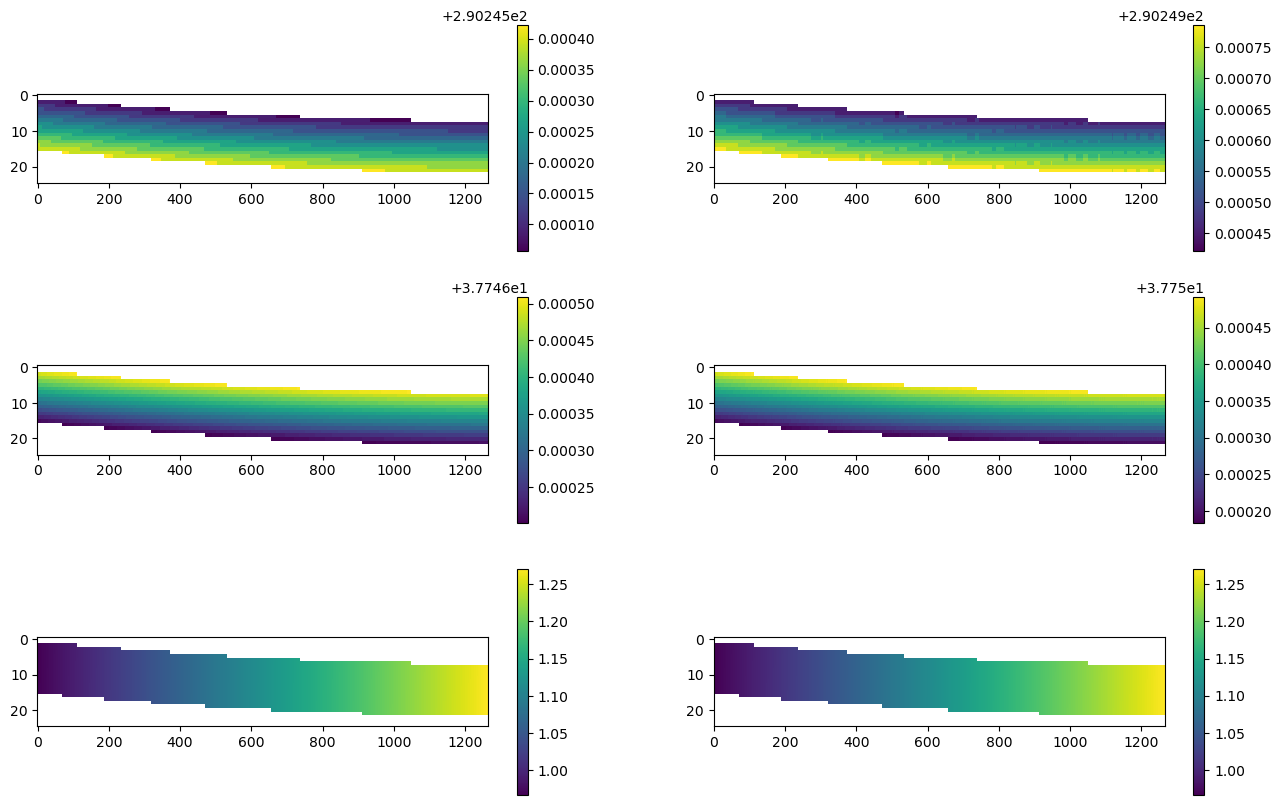

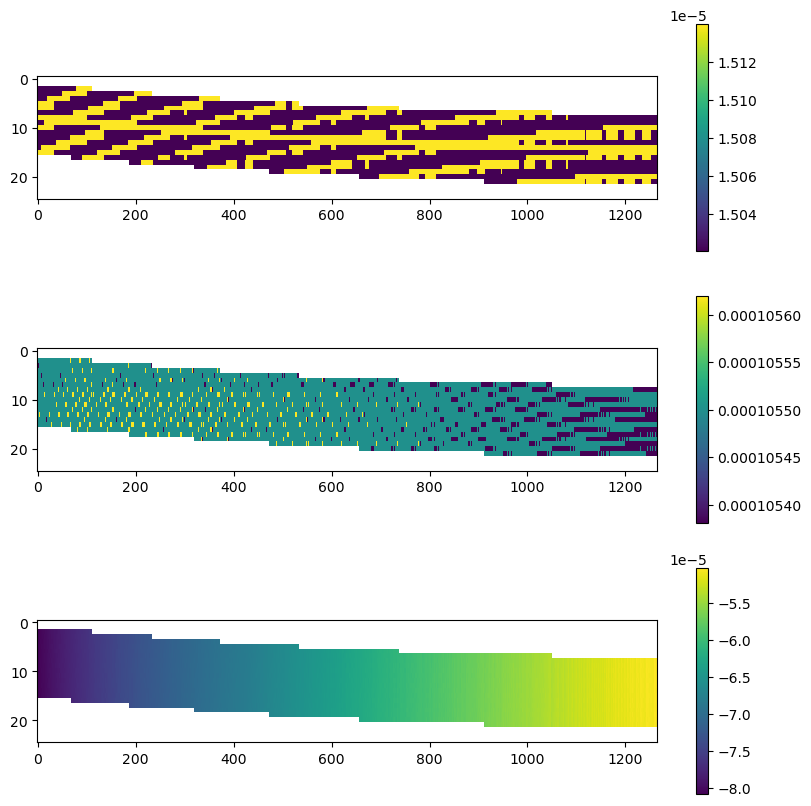

In [110]:
wpred = (xyp @ npres[0]).T.reshape(3, *ss.slitshape)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(wpred[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(wpred[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

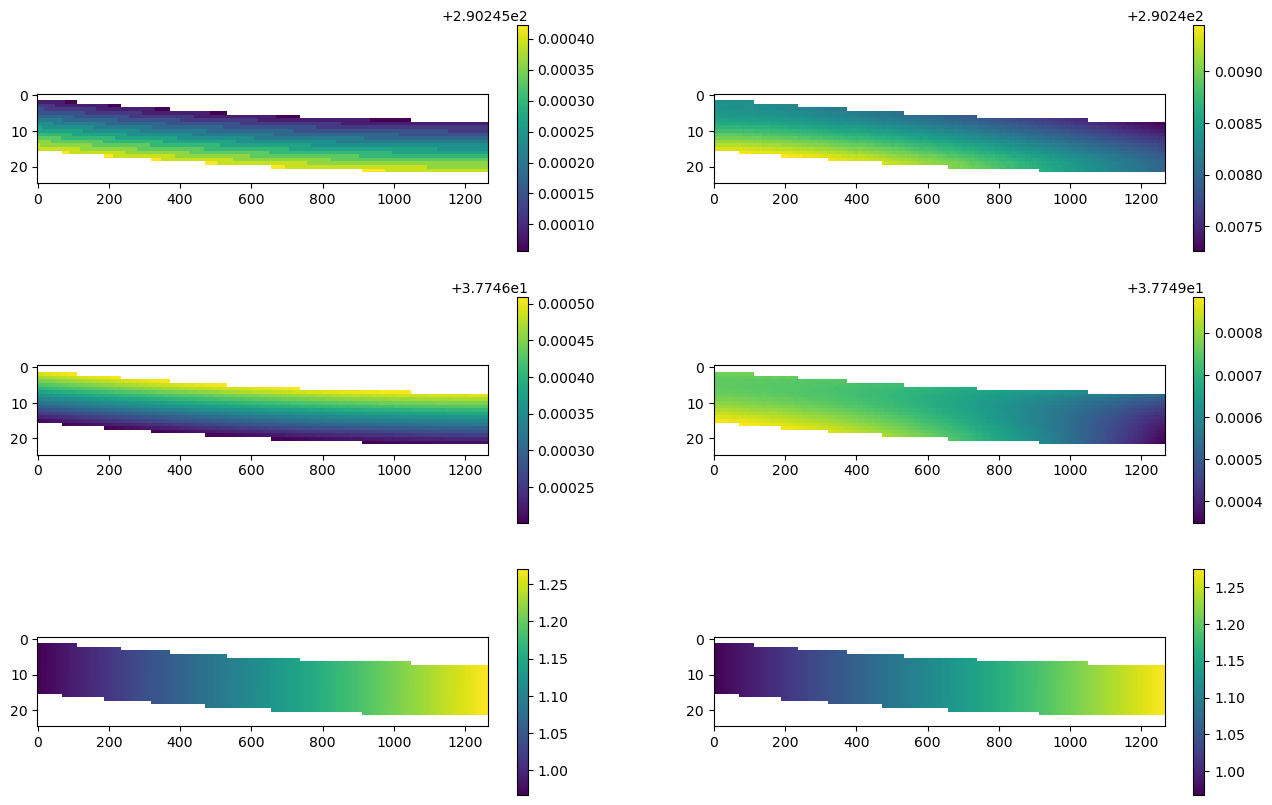

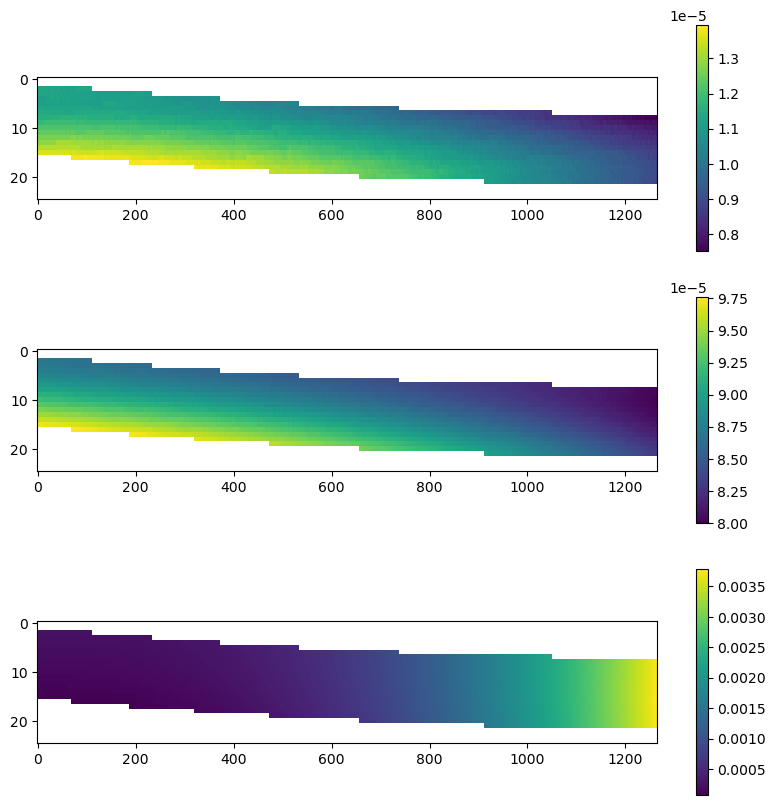

In [ ]:
wpred = (xyp @ jres[0]).T.reshape(3, *ss.slitshape)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(wpred[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(wpred[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

Some conclusions: precision matters here (float vs double), and also the jax lstsq fitter doesn't seem to give good answers?